# Gaussian Mixture Models (GMM) & the EM Algorithm — From Scratch & with Scikit-Learn

**What this notebook covers:**
- The core theory behind GMM and the Expectation-Maximization (EM) algorithm
- Loading and preprocessing a real-world dataset
- A from-scratch GMM/EM implementation using only `numpy` + `scipy.stats`
- A reference implementation using `scikit-learn`'s `GaussianMixture`, with a direct metric comparison
- Visualizations of the resulting Gaussian components and cluster quality
- Hyperparameter experiments (`n_components`, `covariance_type`)
- An interview-style walkthrough of the most commonly asked GMM/EM conceptual question
- Five key takeaways to remember for placement interviews

**Prerequisites:** comfort with Python and `numpy`/`pandas`; basic probability (the Gaussian/normal distribution, likelihood); covariance matrices; and ideally the companion K-Means notebook, since GMM is best understood as a generalization of K-Means.

**Dataset:** [Iris Species — Kaggle](https://www.kaggle.com/datasets/uciml/iris) — 150 flower samples, 4 numeric features (sepal/petal length & width) across 3 species.

**Credits:** Dataset originally collected by Edgar Anderson and popularized by R.A. Fisher (1936); Kaggle mirror curated by user *uciml*. Notebook authored for the Gradientts ML Intern Workflow curriculum.

In [ ]:
import numpy as np                                          # numerical operations; backbone of the from-scratch algorithm
import pandas as pd                                         # loading and manipulating the tabular dataset
import matplotlib.pyplot as plt                              # core plotting library
import matplotlib.patches as patches                         # used to draw covariance ellipses for each Gaussian component
import seaborn as sns                                        # statistical plotting on top of matplotlib

from scipy.stats import multivariate_normal                  # evaluates Gaussian density - needed for our from-scratch E-step
from sklearn.mixture import GaussianMixture                   # reference, production-grade GMM/EM implementation
from sklearn.preprocessing import StandardScaler               # feature scaling (Euclidean/Mahalanobis-sensitive model)
from sklearn.metrics import silhouette_score, adjusted_rand_score  # clustering quality + agreement with true species labels

np.random.seed(42)        # CRITICAL RULE: fix the seed for any random operations -> reproducible results
sns.set_style("whitegrid")
%matplotlib inline

## Part 1: Theory Recap

- A **Gaussian Mixture Model** assumes the data is generated by a weighted combination of `k` multivariate Gaussian distributions, each with its own mean, covariance, and mixing weight — it's a **soft, probabilistic** clustering, unlike K-Means' hard 0/1 assignment.
- **EM (Expectation-Maximization)** fits the mixture's parameters iteratively: the **E-step** computes the "responsibility" (posterior probability) that each Gaussian generated each point; the **M-step** re-estimates every Gaussian's mean, covariance, and weight using those responsibilities as soft weights.
- EM is guaranteed to **monotonically increase the data log-likelihood** at every iteration, so it always converges — but only to a **local maximum**, making initialization and the number of restarts (`n_init`) important.
- **K-Means is a special case of GMM**: it's what you get if every Gaussian is forced to be spherical with equal, fixed variance — that constraint is exactly what turns soft responsibilities into K-Means' hard cluster assignments.
- The `covariance_type` hyperparameter (`spherical` / `diag` / `tied` / `full`) controls how flexible each component's shape can be, trading expressiveness against the number of parameters the model must estimate.

## Loading the Dataset

We use the **Iris** dataset from Kaggle (150 records). Below we load the CSV and inspect its structure.

**Features:**
- `Id` — row identifier (dropped before modeling; not informative)
- `SepalLengthCm`, `SepalWidthCm` — sepal dimensions in cm
- `PetalLengthCm`, `PetalWidthCm` — petal dimensions in cm
- `Species` — the flower species (`Iris-setosa`, `Iris-versicolor`, `Iris-virginica`)

**About the "target variable":** GMM is **unsupervised** — we do **not** feed `Species` into the model. Unlike the K-Means notebook's mall-customer data (which has no labels at all), Iris happens to ship with ground-truth species labels, so we hold `Species` aside purely to **evaluate** how well our unsupervised clusters line up with the real species afterward (via the Adjusted Rand Index) — never to train on.

In [ ]:
df = pd.read_csv("Iris.csv")          # load the real-world Kaggle dataset (no synthetic/generated data)

print("Dataset shape:", df.shape)
print("\n--- df.head() ---")
print(df.head())
print("\n--- df.info() ---")
df.info()
print("\n--- df.describe() ---")
print(df.describe())

Dataset shape: (150, 6)

--- df.head() ---
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), s

## Preprocessing

We check for missing values, drop the non-informative `Id` column, set aside `Species` only for later evaluation, and **standardize** the four numeric features. Standardization matters here because GMM's Gaussian density (and the Mahalanobis-style distance it implies) is scale-sensitive, just like K-Means' Euclidean distance.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())              # confirm there are no nulls to handle in this clean dataset

y_true = df["Species"].values                                        # held out ONLY for evaluation, never used to fit the model
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X_raw = df[feature_cols].values

scaler = StandardScaler()                       # GMM's Gaussian density is scale-sensitive -> features must share a scale
X_scaled = scaler.fit_transform(X_raw)

print("\nScaled feature sample (first 5 rows):")
print(np.round(X_scaled[:5], 3))

Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Scaled feature sample (first 5 rows):
[[-0.901  1.032 -1.341 -1.313]
 [-1.143 -0.125 -1.341 -1.313]
 [-1.385  0.338 -1.398 -1.313]
 [-1.507  0.106 -1.284 -1.313]
 [-1.022  1.263 -1.341 -1.313]]


## Part 2: From-Scratch Implementation

We'll build a `GMMScratch` class implementing the **EM algorithm** using only `numpy` and `scipy.stats.multivariate_normal` (for evaluating Gaussian densities — re-deriving that PDF by hand would obscure the EM logic itself, which is the point of this exercise). The class exposes a k-means-seeded initializer, an `_e_step()` (compute responsibilities), an `_m_step()` (update weights/means/covariances), and `fit()` / `predict()` mirroring scikit-learn's API. Building this by hand makes the soft-assignment mechanic concrete — exactly what interviewers probe when they ask what GMM actually computes that K-Means doesn't.

In [ ]:
class GMMScratch:
    """
    Gaussian Mixture Model fit via the EM algorithm, implemented from scratch
    using numpy (+ scipy.stats only to evaluate the multivariate Gaussian PDF).
    Mirrors the scikit-learn API with fit() and predict() methods.
    """

    def __init__(self, n_components=3, max_iter=100, tol=1e-4, random_state=42):
        self.n_components = n_components      # k: number of Gaussian components
        self.max_iter = max_iter               # safety cap on EM iterations
        self.tol = tol                         # convergence threshold on log-likelihood improvement
        self.random_state = random_state       # INTERVIEW NOTE: EM converges to a LOCAL max -> init matters
        self.weights_ = None                   # mixing weight (pi_k) of each component
        self.means_ = None                     # mean vector of each component
        self.covariances_ = None               # covariance matrix of each component
        self.log_likelihood_history_ = []

    def _init_params(self, X):
        """Seed means from random data points (k-means-style), start with the overall data covariance for every
        component, and equal mixing weights -> a neutral starting point before EM specializes each component."""
        rng = np.random.RandomState(self.random_state)
        n_samples, n_features = X.shape
        idx = rng.choice(n_samples, self.n_components, replace=False)
        self.means_ = X[idx].copy()
        data_cov = np.cov(X.T) + 1e-6 * np.eye(n_features)   # INTERVIEW NOTE: small jitter avoids a singular matrix
        self.covariances_ = np.array([data_cov.copy() for _ in range(self.n_components)])
        self.weights_ = np.full(self.n_components, 1.0 / self.n_components)

    def _e_step(self, X):
        """E-step: for every point, compute the posterior probability ('responsibility') that each
        Gaussian component generated it, via Bayes' rule on the current parameters."""
        n_samples = X.shape[0]
        resp = np.zeros((n_samples, self.n_components))
        for k in range(self.n_components):
            # INTERVIEW NOTE: weight_k * N(x | mean_k, cov_k) is the *joint* probability of (point, component k)
            resp[:, k] = self.weights_[k] * multivariate_normal.pdf(
                X, mean=self.means_[k], cov=self.covariances_[k], allow_singular=True
            )
        total = resp.sum(axis=1, keepdims=True)
        total[total == 0] = 1e-10                       # guard against a row of all-zero densities (numerical underflow)
        resp = resp / total                              # normalize each row -> responsibilities sum to 1 per point
        return resp

    def _log_likelihood(self, X):
        """Total log-likelihood of the data under the current mixture - the quantity EM monotonically increases."""
        n_samples = X.shape[0]
        density = np.zeros(n_samples)
        for k in range(self.n_components):
            density += self.weights_[k] * multivariate_normal.pdf(
                X, mean=self.means_[k], cov=self.covariances_[k], allow_singular=True
            )
        density[density == 0] = 1e-10
        return np.sum(np.log(density))

    def _m_step(self, X, resp):
        """M-step: re-estimate weights, means, and covariances as weighted (by responsibility) statistics."""
        n_samples, n_features = X.shape
        Nk = resp.sum(axis=0)                            # 'effective' number of points assigned to each component
        Nk = np.maximum(Nk, 1e-10)                        # avoid division by zero for a starved component

        self.weights_ = Nk / n_samples
        self.means_ = (resp.T @ X) / Nk[:, np.newaxis]    # INTERVIEW NOTE: weighted mean, not a hard-cluster mean

        new_covs = np.zeros((self.n_components, n_features, n_features))
        for k in range(self.n_components):
            diff = X - self.means_[k]
            # INTERVIEW NOTE: weighted outer-product sum -> the weighted covariance estimate for component k
            new_covs[k] = (resp[:, k][:, np.newaxis, np.newaxis] * np.einsum("ij,ik->ijk", diff, diff)).sum(axis=0) / Nk[k]
            new_covs[k] += 1e-6 * np.eye(n_features)      # regularization: keeps the covariance matrix invertible
        self.covariances_ = new_covs

    def fit(self, X):
        """Run EM until the log-likelihood improvement drops below tol, or max_iter is reached."""
        self._init_params(X)
        prev_ll = -np.inf
        for i in range(self.max_iter):
            resp = self._e_step(X)
            self._m_step(X, resp)
            ll = self._log_likelihood(X)                  # INTERVIEW NOTE: this must never decrease - a useful sanity check
            self.log_likelihood_history_.append(ll)
            if abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll
        self.n_iter_ = len(self.log_likelihood_history_)
        return self

    def predict_proba(self, X):
        """Soft assignment: the full responsibility matrix (probability of each component, per point)."""
        return self._e_step(X)

    def predict(self, X):
        """Hard assignment: the most probable component for each point (argmax of responsibilities)."""
        return np.argmax(self._e_step(X), axis=1)

### Fitting & Evaluating the Scratch Model

We fit `GMMScratch` with `n_components=3` (Iris's three known species) and evaluate it with the **silhouette score** (cluster cohesion/separation, no labels needed) and the **Adjusted Rand Index** against the true `Species` labels (a measure of clustering agreement with ground truth, used here purely for evaluation).

In [ ]:
gmm_scratch = GMMScratch(n_components=3, random_state=42)
gmm_scratch.fit(X_scaled)

scratch_labels = gmm_scratch.predict(X_scaled)
scratch_silhouette = silhouette_score(X_scaled, scratch_labels)
scratch_ari = adjusted_rand_score(y_true, scratch_labels)

print(f"Converged in {gmm_scratch.n_iter_} EM iterations")
print(f"Final log-likelihood:      {gmm_scratch.log_likelihood_history_[-1]:.2f}")
print(f"Scratch Silhouette Score:  {scratch_silhouette:.4f}")
print(f"Scratch Adjusted Rand Index (vs true species): {scratch_ari:.4f}")
print(f"Cluster sizes: {np.bincount(scratch_labels)}")

Converged in 28 EM iterations
Final log-likelihood:      -292.02
Scratch Silhouette Score:  0.3728
Scratch Adjusted Rand Index (vs true species): 0.9039
Cluster sizes: [45 50 55]


## Part 3: Scikit-Learn Implementation

Scikit-learn's `GaussianMixture` runs the same EM core but adds production-grade engineering: smarter initialization (k-means-based by default, or random), multiple random restarts (`n_init`) keeping the best log-likelihood, built-in covariance regularization (`reg_covar`) to avoid singular matrices, and support for all four `covariance_type` options with optimized, vectorized internals. It should reach a similar — often near-identical — solution to our scratch implementation, but more reliably and faster.

In [ ]:
gmm_sklearn = GaussianMixture(n_components=3, covariance_type="full", n_init=10, random_state=42)
sklearn_labels = gmm_sklearn.fit_predict(X_scaled)

sklearn_silhouette = silhouette_score(X_scaled, sklearn_labels)
sklearn_ari = adjusted_rand_score(y_true, sklearn_labels)

print(f"Sklearn final log-likelihood:  {gmm_sklearn.score(X_scaled) * len(X_scaled):.2f}")
print(f"Sklearn Silhouette Score:      {sklearn_silhouette:.4f}")
print(f"Sklearn Adjusted Rand Index (vs true species): {sklearn_ari:.4f}")
print(f"Sklearn iterations to converge: {gmm_sklearn.n_iter_}")

print("\n--- Comparison: Scratch vs Sklearn ---")
comparison = pd.DataFrame({
    "Metric": ["Silhouette Score", "Adjusted Rand Index"],
    "From Scratch": [scratch_silhouette, scratch_ari],
    "Scikit-Learn": [sklearn_silhouette, sklearn_ari],
})
print(comparison.to_string(index=False))

Sklearn final log-likelihood:  -292.03
Sklearn Silhouette Score:      0.3728
Sklearn Adjusted Rand Index (vs true species): 0.9039
Sklearn iterations to converge: 19

--- Comparison: Scratch vs Sklearn ---
             Metric  From Scratch  Scikit-Learn
   Silhouette Score      0.372773      0.372773
Adjusted Rand Index      0.903874      0.903874


## Visualizing the Components

Two plots: **(1)** the fitted Gaussian components in *Petal Length vs. Petal Width* space (the most separable feature pair for Iris), with each component's 2-standard-deviation covariance ellipse drawn on top — the signature GMM visualization that K-Means cannot produce, since K-Means has no covariance concept. **(2)** a heatmap of true species vs. predicted cluster, showing how purely unsupervised clustering recovers the real species groupings almost perfectly.

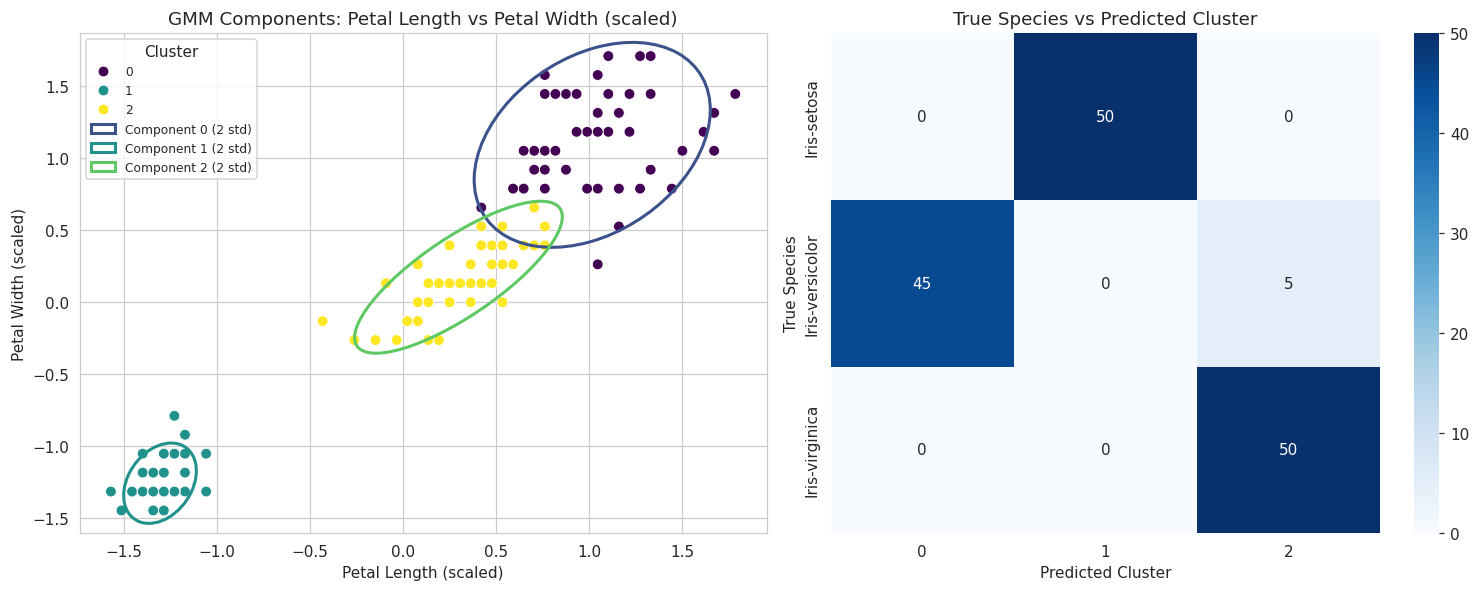

In [ ]:
def draw_ellipse(mean, cov, ax, **kwargs):
    """Draw a 2-std-dev covariance ellipse for a single 2D Gaussian component."""
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * 2 * np.sqrt(eigvals)              # 2 standard deviations along each principal axis
    ellipse = patches.Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

# Refit a 2D-only GMM on just Petal Length & Petal Width so the ellipses match what we plot
petal_idx = [feature_cols.index("PetalLengthCm"), feature_cols.index("PetalWidthCm")]
X_petals = X_scaled[:, petal_idx]
gmm_2d = GaussianMixture(n_components=3, covariance_type="full", n_init=10, random_state=42).fit(X_petals)
labels_2d = gmm_2d.predict(X_petals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: scatter + covariance ellipses in petal-feature space
sns.scatterplot(
    x=X_petals[:, 0], y=X_petals[:, 1], hue=labels_2d, palette="viridis",
    s=50, ax=axes[0], legend="full"
)
colors = sns.color_palette("viridis", 3)
for k in range(3):
    draw_ellipse(gmm_2d.means_[k], gmm_2d.covariances_[k], axes[0],
                 edgecolor=colors[k], facecolor="none", linewidth=2, label=f"Component {k} (2 std)")
axes[0].set_title("GMM Components: Petal Length vs Petal Width (scaled)")
axes[0].set_xlabel("Petal Length (scaled)")
axes[0].set_ylabel("Petal Width (scaled)")
axes[0].legend(title="Cluster", loc="upper left", fontsize=8)

# Plot 2: heatmap of true species vs predicted cluster (full-feature sklearn model)
crosstab = pd.crosstab(y_true, sklearn_labels)
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("True Species vs Predicted Cluster")
axes[1].set_xlabel("Predicted Cluster")
axes[1].set_ylabel("True Species")

plt.tight_layout()
plt.show()

## Part 4: Hyperparameter Experiments

The two hyperparameters that matter most for GMM are **`n_components`** — too few merges genuinely distinct groups, too many lets components overfit individual points — and **`covariance_type`**, which controls how flexible each component's shape can be (`spherical` is most restrictive, `full` is most flexible but needs the most data per component to estimate reliably). Unlike K-Means' inertia, GMM gives us a principled, complexity-penalized way to choose `n_components`: the **Bayesian/Akaike Information Criterion (BIC/AIC)**, which we use below instead of a plain inertia curve.

Best n_components by BIC: 2
spherical  -> mean CV log-likelihood = -4.056, std = 0.296
diag       -> mean CV log-likelihood = -3.083, std = 0.244
tied       -> mean CV log-likelihood = -2.657, std = 0.128
full       -> mean CV log-likelihood = -2.427, std = 0.142


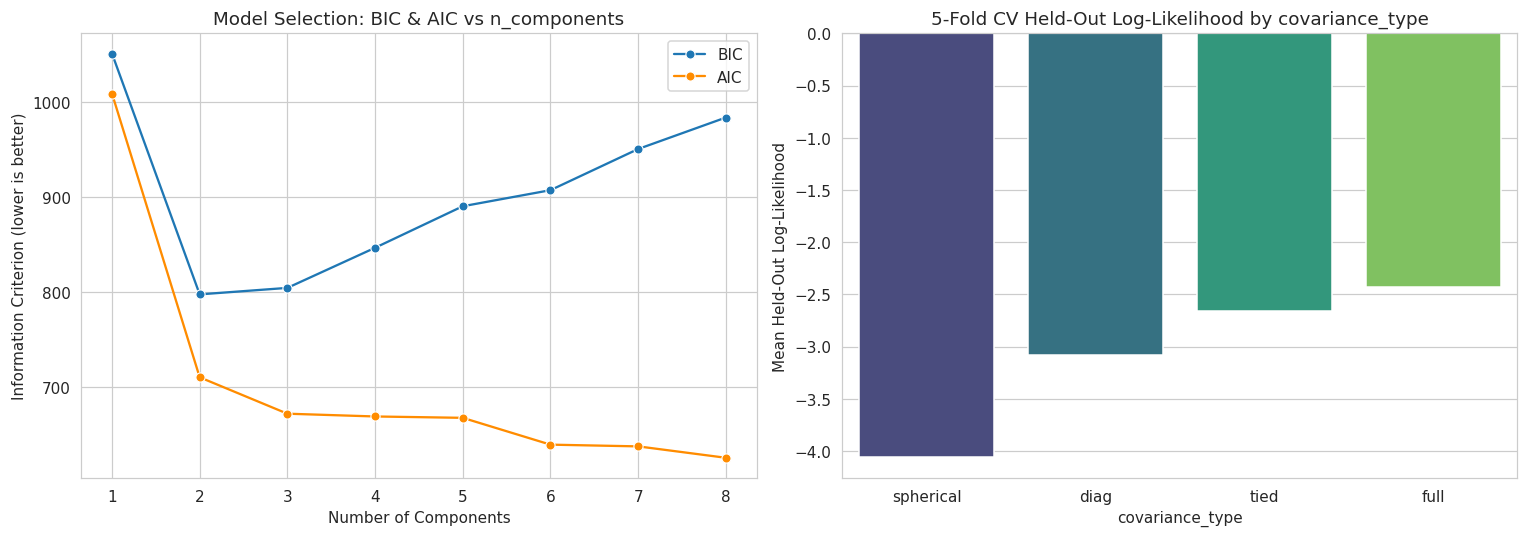

In [ ]:
# --- Experiment 1: vary n_components, track BIC and AIC (lower = better, accounts for model complexity) ---
n_components_range = range(1, 9)
bics, aics = [], []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type="full", n_init=10, random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=list(n_components_range), y=bics, marker="o", ax=axes[0], label="BIC")
sns.lineplot(x=list(n_components_range), y=aics, marker="o", ax=axes[0], color="darkorange", label="AIC")
axes[0].set_title("Model Selection: BIC & AIC vs n_components")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Information Criterion (lower is better)")
axes[0].legend()

best_n_bic = list(n_components_range)[int(np.argmin(bics))]
print(f"Best n_components by BIC: {best_n_bic}")

# --- Experiment 2: vary covariance_type at the chosen n_components, compare BIC + cross-validated log-likelihood ---
from sklearn.model_selection import KFold

cov_types = ["spherical", "diag", "tied", "full"]
cv_scores = {ct: [] for ct in cov_types}
kf = KFold(n_splits=5, shuffle=True, random_state=42)   # cross-validation for a held-out log-likelihood estimate

for ct in cov_types:
    for train_idx, test_idx in kf.split(X_scaled):
        gmm = GaussianMixture(n_components=3, covariance_type=ct, n_init=5, random_state=42)
        gmm.fit(X_scaled[train_idx])
        cv_scores[ct].append(gmm.score(X_scaled[test_idx]))   # average held-out log-likelihood per sample

mean_scores = [np.mean(cv_scores[ct]) for ct in cov_types]
sns.barplot(x=cov_types, y=mean_scores, ax=axes[1], hue=cov_types, palette="viridis", legend=False)
axes[1].set_title("5-Fold CV Held-Out Log-Likelihood by covariance_type")
axes[1].set_xlabel("covariance_type")
axes[1].set_ylabel("Mean Held-Out Log-Likelihood")

plt.tight_layout()
plt.show()

for ct in cov_types:
    print(f"{ct:10s} -> mean CV log-likelihood = {np.mean(cv_scores[ct]):.3f}, std = {np.std(cv_scores[ct]):.3f}")

## Part 5: Interview Corner

**Q: How exactly does GMM differ from K-Means, and what does the E-step actually compute?**

K-Means assigns every point to exactly one cluster (a **hard**, 0/1 assignment) based purely on nearest-centroid Euclidean distance, implicitly assuming every cluster is spherical and equally sized. GMM instead assigns every point a **soft, probabilistic** membership in *every* component — the E-step computes the **responsibility** `r_ik` = the posterior probability that component `k` generated point `i`, via Bayes' rule: `r_ik ∝ weight_k × N(x_i | mean_k, cov_k)`. Because each component has its own full covariance matrix (under `covariance_type="full"`), GMM can fit elongated, correlated, differently-sized clusters that K-Means structurally cannot represent.

This is also why **K-Means is a special case of GMM**: force every component's covariance to be spherical and identical across components, and force the responsibilities to be hard (argmax instead of a soft distribution), and the EM updates reduce exactly to Lloyd's algorithm's assign/update steps. A strong interview answer leads with this hard-vs-soft distinction, then connects it to *why* GMM needs more data per cluster to reliably estimate full covariance matrices — the classic expressiveness-vs-overfitting trade-off.

## Key Takeaways

- GMM models data as a weighted mixture of Gaussians and fits it via **EM**: the E-step computes soft per-point responsibilities, the M-step re-estimates each component's weight/mean/covariance from those responsibilities — and the data log-likelihood **never decreases** across iterations.
- GMM is a **strict generalization of K-Means**: forcing spherical, equal covariances and hard assignments collapses GMM's EM updates into Lloyd's algorithm.
- EM converges only to a **local maximum** of the likelihood, so initialization and multiple restarts (`n_init`) matter just as much as they do for K-Means.
- Choosing `n_components` should use **BIC or AIC**, not raw inertia — these information criteria explicitly penalize model complexity, since log-likelihood alone (like inertia) only ever improves as you add components.
- The `covariance_type` hyperparameter is the key expressiveness/overfitting lever: `full` covariance can fit elongated, correlated clusters but needs more data per component, while `spherical`/`diag`/`tied` trade flexibility for stability on smaller datasets.